In [ ]:
print("HELLO WORLD")

HELLO WORLD


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory

### Compare best runs

real	-0.045971532
complex	-0.0459737197


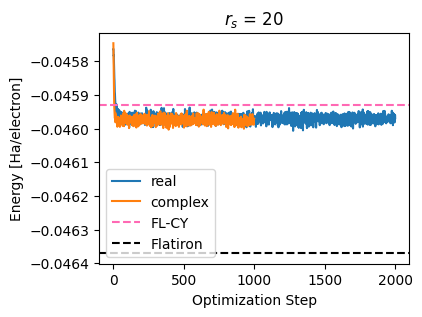

real	-0.031807329
complex	-0.0318084956


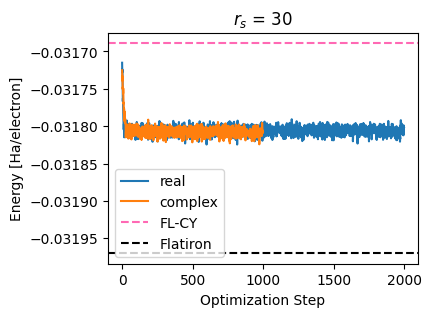

real	-0.0243685931
complex	-0.0243691893


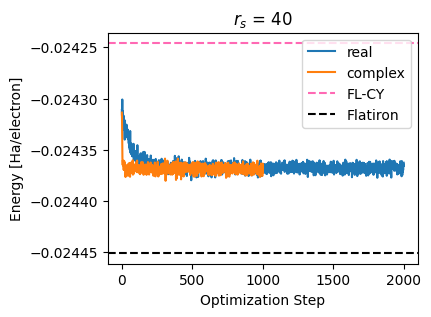

real	-0.0197740944
complex	-0.0197735993


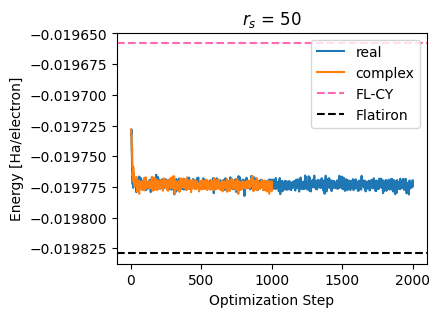

In [17]:
path = "{}/rs{}_best/{}"

compare_vals = [
    ( "joint/dynamic-smw" , "real" ),
    ( "complex_vmc/dynamic" , "complex" ),
]
compare_vals = [
    ( "gaussian-reference/MP-init-gaussian" , "real" ),
    ( "complex_vmc/static-MP" , "complex" ),
]
compare_vals = [
    ( "gaussian-reference/gaussian" , "real" ),
    ( "complex_vmc/static-gaussian" , "complex" ),
]

for r_ws in ["20", "30", "40", "50"]:

    plt.figure(figsize=(4,3))

    # "r_ws" : ( FL_ref , WC_ref, flatiron )
    hard_vals = {
        "10" : ( -0.084474 , np.nan , np.nan ),
        "20" : ( -0.045929 , -0.045975 , -0.04637 ),
        "30" : ( -0.031689 , -0.031807 , -0.03197 ),
        "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
        "50" : ( -0.0196580 , np.nan , -0.019829 ),
    }

    for (filename, label) in compare_vals:

        energy_filename = path.format(
            filename, str(r_ws), "energy_traj.txt"
        )
        with open(energy_filename) as f:
            energy_traj = np.array([complex(line.strip()) for line in f])

        (mean,_) = trajectory.getStatistics(path.format(
            filename, r_ws, "statistics.txt"
        ))

        print("{}\t{}".format(label, mean))

        if mean is None:
            continue;
        
        plt.plot(energy_traj, label=label)

    plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
    plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')

    plt.title(f"$r_s$ = " + str(r_ws))
    plt.xlabel("Optimization Step")
    plt.ylabel("Energy [Ha/electron]")
    plt.legend()
    plt.show()